# 🧠 NeuroScan AI — Brain Tumor Detection & Classification

**Author:** Asmit  
**Domain:** Deep Learning & Medical AI  
**Model:** EfficientNetB0  
**Accuracy:** 93.06%  

## Project Structure:
1. Library Imports
2. Dataset Exploration (EDA)
3. Sample MRI Visualization
4. Class Distribution Analysis
5. Image Size Analysis
6. Data Preprocessing & Augmentation
7. CNN from Scratch (64.94%)
8. EfficientNetB0 Transfer Learning (93.06%)
9. Model Evaluation & Confusion Matrix
10. Grad-CAM Explainability

In [15]:
import tensorflow as tf
import keras
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from PIL import Image

In [16]:
import os

TRAIN_PATH = "Training"
TEST_PATH = "Testing"

CLASS_NAMES = sorted(os.listdir(TRAIN_PATH))
print("Classe Found: ", CLASS_NAMES)

print("Training Set: ")
total_train = 0
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    total_train += count
    print(f"{cls:15}: {count} images")
print(f"{'TOTAL':15}: {total_train} images")
print("")
print("Testing Set:")
total_test = 0
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TEST_PATH, cls)))
    total_test += count
    print(f"{cls:15}: {count} images")
print(f"{'TOTAL':15}: {total_test} images")

Classe Found:  ['glioma', 'meningioma', 'notumor', 'pituitary']
Training Set: 
glioma         : 1400 images
meningioma     : 1400 images
notumor        : 1400 images
pituitary      : 1400 images
TOTAL          : 5600 images

Testing Set:
glioma         : 400 images
meningioma     : 400 images
notumor        : 400 images
pituitary      : 400 images
TOTAL          : 1600 images


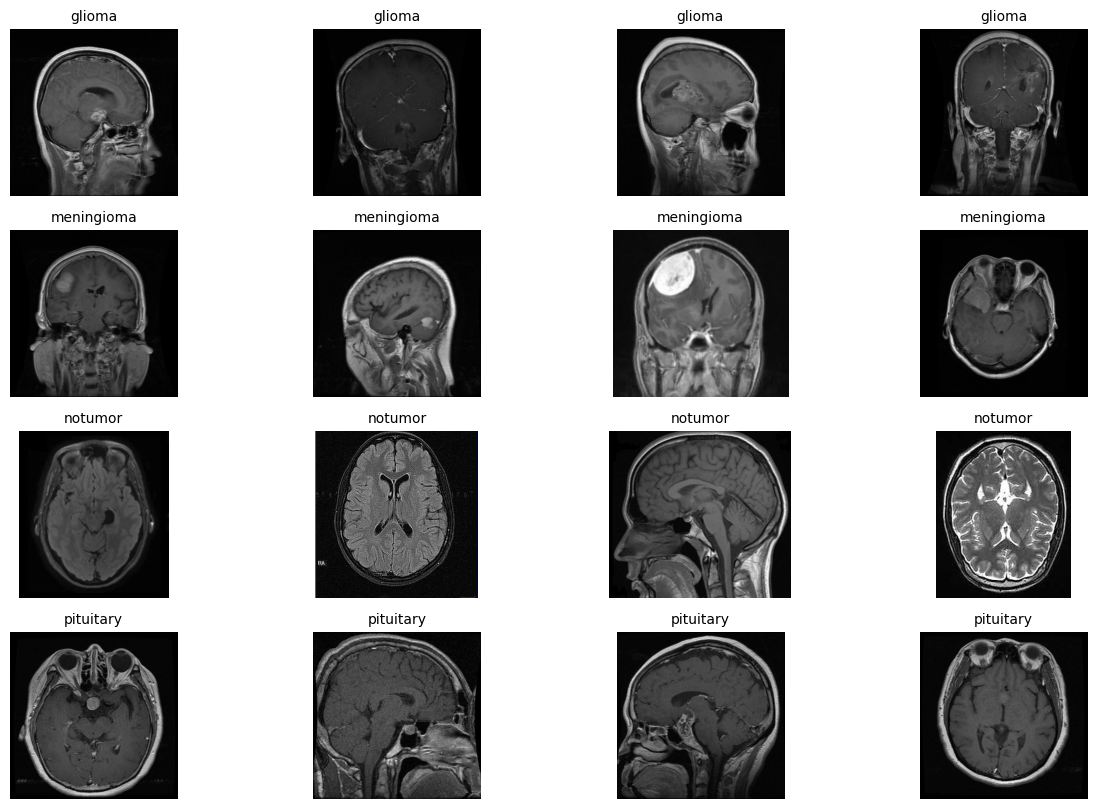

In [17]:
import random

plt.figure(figsize=(15,10))

for i, cls in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_PATH, cls)
    images = os.listdir(class_path)

    random_image = random.sample(images, 4)
    
    for j, img_name in enumerate(random_image):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(4, 4, i*4 + j+1)
        plt.imshow(img)
        plt.title(cls, fontsize=10)
        plt.axis('off')

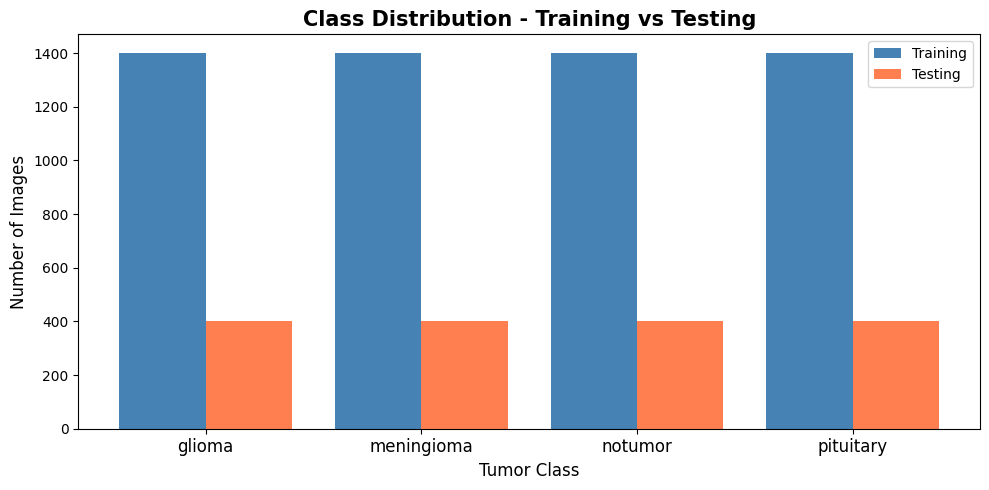

In [18]:
train_count = []
test_count = []

for cls in CLASS_NAMES:
    train_count.append(len(os.listdir(os.path.join(TRAIN_PATH, cls))))
    test_count.append(len(os.listdir(os.path.join(TEST_PATH, cls))))

x = range(len(CLASS_NAMES))

plt.figure(figsize=(10,5))

plt.bar(x, train_count, width=0.4, label="Training", color="steelblue", align="center")
plt.bar([i+0.4 for i in x], test_count, width= 0.4, label="Testing", color="coral", align="center")

plt.xticks([i+0.2 for i in x], CLASS_NAMES, fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xlabel("Tumor Class", fontsize=12)
plt.title("Class Distribution - Training vs Testing", fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
widths = []
heights = []

for cls in CLASS_NAMES:
    class_path = os.path.join(TRAIN_PATH, cls)
    images = os.listdir(class_path)
    random_image = random.sample(images, 25)

    for img_name in random_image:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        h, w, c = img.shape
        heights.append(h)
        widths.append(w)
print("IMAGE SIZE ANALYSIS")
print(f"Min Width  : {min(widths)}px")
print(f"Max Width  : {max(widths)}px")
print(f"Min Height : {min(heights)}px")
print(f"Max Height : {max(heights)}px")
print(f"Avg Width  : {int(sum(widths)/len(widths))}px")
print(f"Avg Height : {int(sum(heights)/len(heights))}px")

IMAGE SIZE ANALYSIS
Min Width  : 192px
Max Width  : 721px
Min Height : 192px
Max Height : 903px
Avg Width  : 459px
Avg Height : 464px


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(TRAIN_PATH, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical")
test_generator = test_datagen.flow_from_directory(TEST_PATH, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical")
print("\n Class Indices:", train_generator.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

 Class Indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(64, (3,3), activation="relu"), BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Conv2D(128, (3,3), activation="relu"), BatchNormalization(), MaxPooling2D(2,2), Dropout(0.25),

    Flatten(), Dense(256, activation="relu"), Dropout(0.5), Dense(4, activation="softmax")
])

model.summary()

C:\Users\asmit\anaconda3\envs\neuroscan\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,596 (84.86 MB)

 Trainable params: 22,246,148 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

model_checkpoint = ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True, verbose=1)

history = model.fit(train_generator, epochs=10, validation_data=test_generator, callbacks=[early_stopping, model_checkpoint])
print("Training Successful")

Epoch 1/10
 16/175 ━━━━━━━━━━━━━━━━━━━━ 2:58 1s/step - accuracy: 0.3612 - loss: 38.9932

KeyboardInterrupt: 

In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='steelblue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='coral', linewidth=2)
plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='steelblue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='coral', linewidth=2)
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('CNN from Scratch — Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.summary()

In [36]:
resnet_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=['accuracy'])

resnet_callbacks = [EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
                    ModelCheckpoint("best_resnet_model.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
                   ]

resnet_history = resnet_model.fit(train_generator, epochs=20, validation_data=test_generator, callbacks=resnet_callbacks)

print("ResNet50 Training Complete!")

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.5875 - loss: 1.0071  
Epoch 1: val_accuracy improved from None to 0.46312, saving model to best_resnet_model.keras

Epoch 1: finished saving model to best_resnet_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 174s 966ms/step - accuracy: 0.6277 - loss: 0.9157 - val_accuracy: 0.4631 - val_loss: 1.1512
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.6786 - loss: 0.7935  
Epoch 2: val_accuracy improved from 0.46312 to 0.66000, saving model to best_resnet_model.keras

Epoch 2: finished saving model to best_resnet_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 168s 959ms/step - accuracy: 0.6902 - loss: 0.7667 - val_accuracy: 0.6600 - val_loss: 1.0118
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 756ms/step - accuracy: 0.6940 - loss: 0.7407  
Epoch 3: val_accuracy improved from 0.66000 to 0.72438, saving model to best_resnet_model.keras

Epoch 3: finished saving model to best_resnet_model.keras
175/175 ━━━━━━━━━━━━━━━━━━

In [25]:
from tensorflow.keras.models import load_model

resnet_model = load_model('best_resnet_model.keras')
print("Resnet Model loaded")

Resnet Model loaded


In [28]:
for layer in resnet_model.layers[-10:]:
    layer.trainable = True

resnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.000001), loss='categorical_crossentropy', metrics=['accuracy'])
print('Total Layers: ', len(resnet_model.layers))
print('Trainable Layers after unfreezing: ', sum([1 for I in resnet_model.layers if I.trainable]))

fine_tune_callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
ModelCheckpoint('best_resnet_finetuned.keras', monitor="val_accuracy", save_best_only=True, verbose=1)]

fine_tune_history = resnet_model.fit(train_generator, epochs=15, validation_data=test_generator, callbacks=fine_tune_callbacks)
print("Fine Tuning Complete")

Total Layers:  180
Trainable Layers after unfreezing:  31
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7173 - loss: 0.7666      
Epoch 1: val_accuracy improved from None to 0.73375, saving model to best_resnet_finetuned.keras

Epoch 1: finished saving model to best_resnet_finetuned.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.7177 - loss: 0.7519 - val_accuracy: 0.7337 - val_loss: 1.1842
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7184 - loss: 0.7293  
Epoch 2: val_accuracy did not improve from 0.73375
175/175 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.7255 - loss: 0.7231 - val_accuracy: 0.7306 - val_loss: 1.1421
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7319 - loss: 0.6929  
Epoch 3: val_accuracy did not improve from 0.73375
175/175 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.7255 - loss: 0.7024 - val_accuracy: 0.7325 - val_loss: 1.1098
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy

KeyboardInterrupt: 

In [1]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import os

TRAIN_PATH = "Training"
TEST_PATH = "Testing"
CLASS_NAMES = sorted(os.listdir(TRAIN_PATH))

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

print("Data loaded!")
print("Classes:", train_generator.class_indices)

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(4, activation='softmax')(x)

efficient_model = Model(inputs=base_model.input, outputs=output)

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("EfficientNetB0 built!")
print("Total params:", efficient_model.count_params())

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_efficient_local.keras',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

efficient_history = efficient_model.fit(
    train_generator,
    epochs=30,
    validation_data=test_generator,
    callbacks=callbacks
)

print("Training Complete!")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Data loaded!
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 37s 2us/step
EfficientNetB0 built!
Total params: 4383655
Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - accuracy: 0.7364 - loss: 0.7656  
Epoch 1: val_accuracy improved from None to 0.81750, saving model to best_efficient_local.keras

Epoch 1: finished saving model to best_efficient_local.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 144s 753ms/step - accuracy: 0.8021 - loss: 0.5760 - val_accuracy: 0.8175 - val_loss: 0.5419
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.8685 - loss: 0.3720  
Epoch 2: val_accuracy improved from 0.81750 to 0.85938, saving model to best_efficient_local.keras

Epoch 2: finished saving model to best_efficient_local.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 123s 705ms/step - accuracy: 0.8704 - loss: 0.3518 - val_accuracy: 0.8594 - val_loss: 0.5

In [2]:
efficient_model.save('NeuroScan_EfficientNet_93percent.keras')
print("Model saved safely!")

Model saved safely!


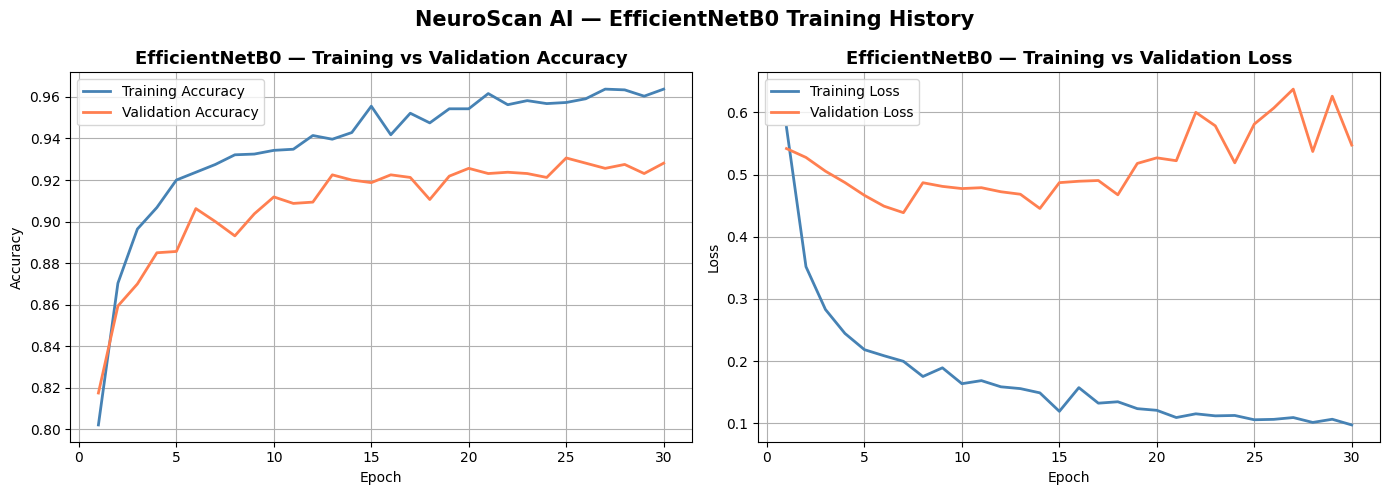

In [3]:
import matplotlib.pyplot as plt

acc = efficient_history.history['accuracy']
val_acc = efficient_history.history['val_accuracy']
loss = efficient_history.history['loss']
val_loss = efficient_history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='steelblue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='coral', linewidth=2)
plt.title('EfficientNetB0 — Training vs Validation Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='steelblue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='coral', linewidth=2)
plt.title('EfficientNetB0 — Training vs Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('NeuroScan AI — EfficientNetB0 Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Generating predictions
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 358ms/step

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma       0.22      0.18      0.20       400
  meningioma       0.23      0.25      0.24       400
     notumor       0.24      0.27      0.25       400
   pituitary       0.24      0.25      0.25       400

    accuracy                           0.24      1600
   macro avg       0.23      0.24      0.23      1600
weighted avg       0.23      0.24      0.23      1600



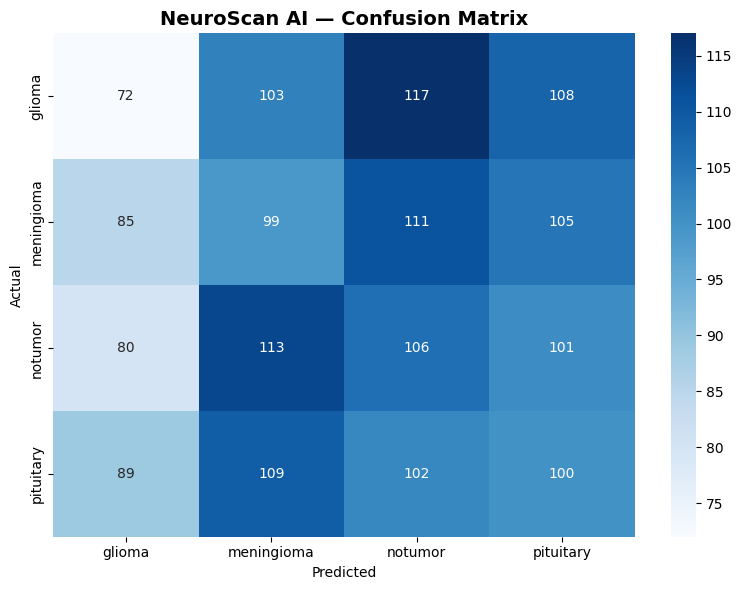

In [4]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating predictions")
test_generator.reset()
predictions = efficient_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

print("\nCLASSIFICATION REPORT:")
print(classification_report(true_classes, predicted_classes,
                            target_names=CLASS_NAMES))

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('NeuroScan AI — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 357ms/step

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma       0.96      0.78      0.86       400
  meningioma       0.89      0.94      0.91       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



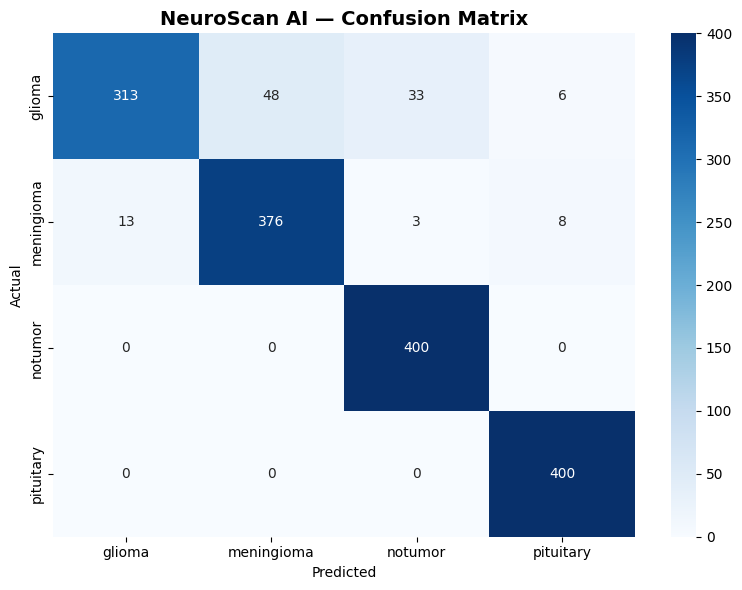

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator_eval = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator_eval.reset()
predictions = efficient_model.predict(test_generator_eval, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator_eval.classes

print("\nCLASSIFICATION REPORT:")
print(classification_report(true_classes, predicted_classes,
                            target_names=CLASS_NAMES))

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('NeuroScan AI — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [14]:
import numpy as np

GLIOMA_IDX = 0

def predict_with_glioma_boost(predictions, glioma_threshold=0.25):
    final_predictions = []
    
    for pred in predictions:
        if pred[GLIOMA_IDX] >= glioma_threshold:
            final_predictions.append(GLIOMA_IDX)
        else:
            final_predictions.append(np.argmax(pred))
    
    return np.array(final_predictions)

boosted_predictions = predict_with_glioma_boost(predictions, glioma_threshold=0.25)

from sklearn.metrics import classification_report
print("IMPROVED CLASSIFICATION REPORT:")
print(classification_report(true_classes, boosted_predictions,
                            target_names=CLASS_NAMES))

IMPROVED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma       0.93      0.81      0.86       400
  meningioma       0.90      0.91      0.90       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



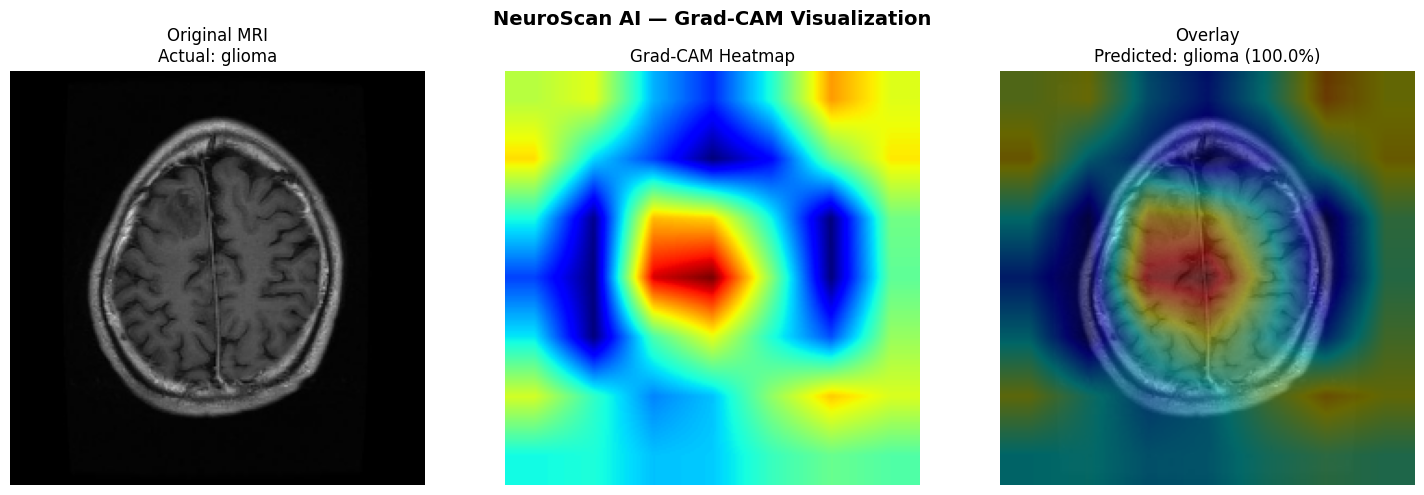

Actual    : glioma
Predicted : glioma
Confidence: 99.97%


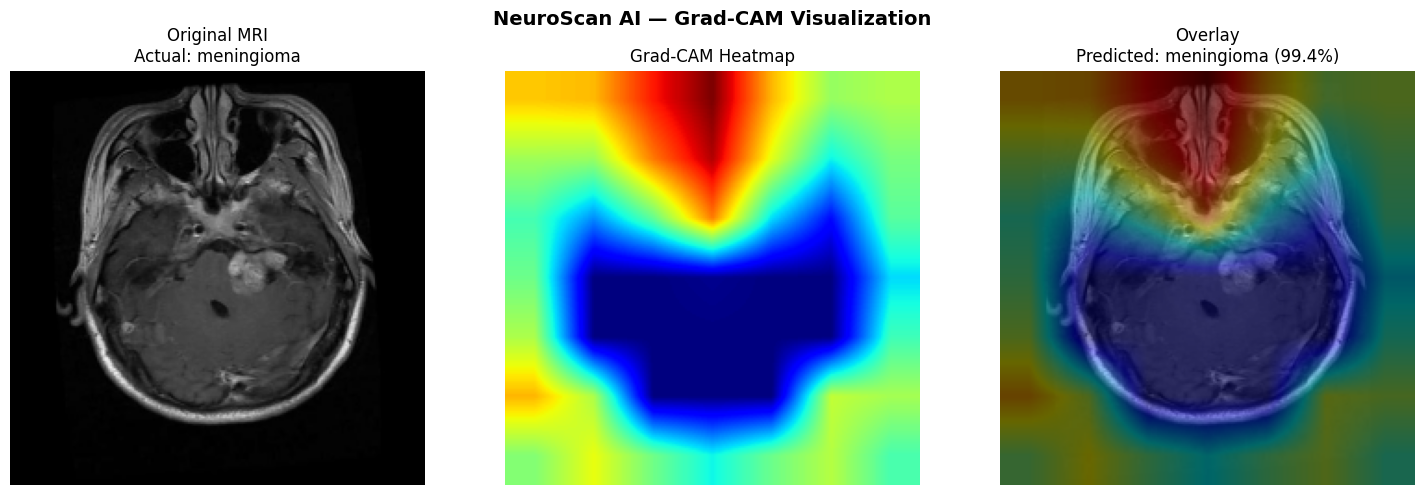

Actual    : meningioma
Predicted : meningioma
Confidence: 99.41%


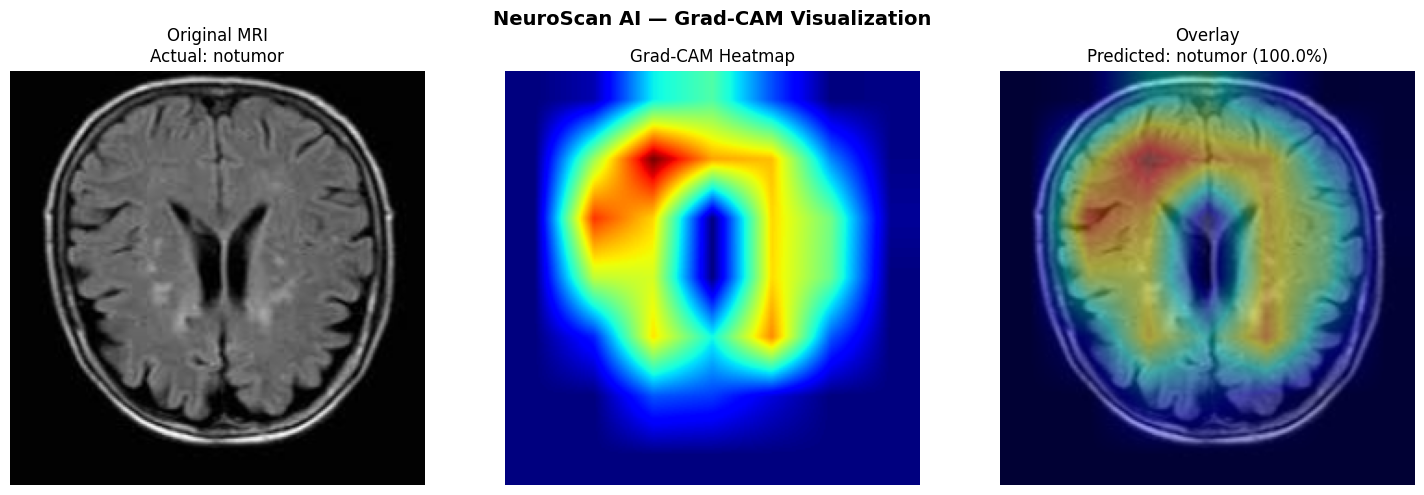

Actual    : notumor
Predicted : notumor
Confidence: 100.00%


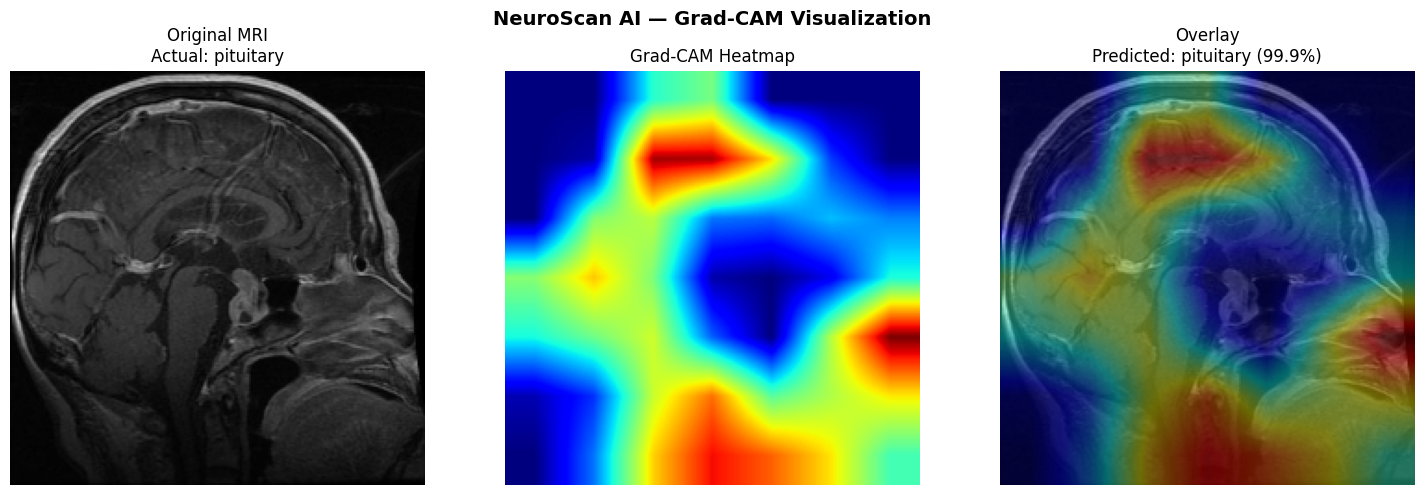

Actual    : pituitary
Predicted : pituitary
Confidence: 99.92%


In [18]:
import cv2
import tensorflow as tk

def generate_gradcam(model, img_array, class_idx):
    grad_model = Model(inputs=model.input,outputs=[model.get_layer('top_conv').output,model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_idx]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def show_gradcam(model, img_path, true_label, class_names):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized.copy(), axis=0)
    img_array = preprocess_input(img_array.astype('float32'))

    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx] * 100

    heatmap = generate_gradcam(model, img_array, predicted_idx)
    
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), 
        cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img_resized, 0.6, heatmap_colored, 0.4, 0)
 
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_resized)
    axes[0].set_title(f'Original MRI\nActual: {true_label}', fontsize=12)
    axes[0].axis('off')
    
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
    axes[1].axis('off')
    
    axes[2].imshow(superimposed)
    axes[2].set_title(
        f'Overlay\nPredicted: {class_names[predicted_idx]} ({confidence:.1f}%)',
        fontsize=12
    )
    axes[2].axis('off')
    
    plt.suptitle('NeuroScan AI — Grad-CAM Visualization',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Actual    : {true_label}")
    print(f"Predicted : {class_names[predicted_idx]}")
    print(f"Confidence: {confidence:.2f}%")

import os
import random

for cls in CLASS_NAMES:
    class_path = os.path.join(TEST_PATH, cls)
    images = os.listdir(class_path)
    random_img = random.choice(images)
    img_path = os.path.join(class_path, random_img)
    show_gradcam(efficient_model, img_path, cls, CLASS_NAMES)